In [1]:
import pandas as pd 
import re

In [32]:
file_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS"
figure_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\figures"

In [4]:
df = pd.read_csv(f'{file_path}\imputed_normalized_BatchCorrected_drugnames_log2.csv', index_col = 0)

In [41]:
file_path_manual = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS"

manual_wttest = pd.read_csv(f'{file_path_manual}\drugs_dysregulation_summary_Ttest.csv',index_col = 0)

In [42]:
manual_wttest.columns

Index(['protein', 'drug', 't_stat', 'p_value', 'mean_drug', 'mean_DMSO',
       'log2FC', 'p_value_adj'],
      dtype='object')

In [43]:
import pandas as pd
import numpy as np

def build_drug_correlation_matrix(
    df,
    value_col="log2FC",
    drug_col="drug",
    protein_col="protein",
    method="spearman",
    min_proteins_per_drug=50,
    min_non_na_per_protein=2
):
    """
    Build drug-drug correlation matrix from long-format differential proteomics table.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain at least [protein_col, drug_col, value_col].
    value_col : str
        Column used to calculate similarity, usually 'log2FC'.
    drug_col : str
        Drug column name.
    protein_col : str
        Protein column name.
    method : str
        Correlation method: 'spearman' or 'pearson'.
    min_proteins_per_drug : int
        Minimum number of quantified proteins required for a drug to be kept.
    min_non_na_per_protein : int
        Minimum number of drugs with non-NA values required for a protein to be kept.

    Returns
    -------
    matrix : pd.DataFrame
        Protein x drug matrix.
    corr_mat : pd.DataFrame
        Drug x drug correlation matrix.
    """
    use_cols = [protein_col, drug_col, value_col]
    dat = df[use_cols].copy()

    # remove duplicated protein-drug entries if any
    dat = dat.dropna(subset=[protein_col, drug_col, value_col])
    dat = dat.groupby([protein_col, drug_col], as_index=False)[value_col].mean()

    # pivot to protein x drug matrix
    matrix = dat.pivot(index=protein_col, columns=drug_col, values=value_col)

    # keep drugs with enough quantified proteins
    keep_drugs = matrix.columns[matrix.notna().sum(axis=0) >= min_proteins_per_drug]
    matrix = matrix[keep_drugs]

    # keep proteins observed in enough drugs
    matrix = matrix.loc[matrix.notna().sum(axis=1) >= min_non_na_per_protein]

    # correlation across drugs
    corr_mat = matrix.corr(method=method)

    return matrix, corr_mat

In [44]:
drug_matrix, corr_mat = build_drug_correlation_matrix(
    df=manual_wttest,
    value_col="log2FC",
    method="spearman"
)

In [29]:
# drug_matrix.to_csv(f'{file_path_manual}\drugs_log2FCvsDMSO.csv')

In [20]:
spearman_all = drug_matrix.corr(method="spearman")
pearson_all  = drug_matrix.corr(method="pearson")

In [30]:
spearman_all.to_csv(f'{file_path_manual}\overall_corr_spearman.csv')
pearson_all.to_csv(f'{file_path_manual}\overall_corr_pearson.csv')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    spearman_all,
    cmap="vlag",
    center=0,
    figsize=(14, 14)
)
plt.show()

In [34]:
spearman_all2 = pd.read_csv(f'{file_path_manual}\overall_corr_spearman.csv',index_col = 0 )
pearman_all2 = pd.read_csv(f'{file_path_manual}\overall_corr_pearson.csv',index_col = 0)

In [37]:
def get_high_corr_pairs(pearson_mat, spearman_mat, threshold=0.7):
    # 确保两个矩阵顺序一致
    pearson_mat = pearson_mat.loc[spearman_mat.index, spearman_mat.columns]

    # 条件筛选（同时满足）
    mask = (pearson_mat > threshold) & (spearman_mat > threshold)

    # 转成长格式
    df = mask.stack().reset_index()
    df.columns = ["drug1", "drug2", "keep"]

    # 只保留 True
    df = df[df["keep"]].drop(columns="keep")

    # 去掉自己和自己
    df = df[df["drug1"] != df["drug2"]]

    # 去重（A-B 和 B-A）
    df["pair"] = df.apply(lambda x: tuple(sorted([x["drug1"], x["drug2"]])), axis=1)
    df = df.drop_duplicates("pair").drop(columns="pair")

    # 加上相关系数数值（方便后续排序/画图）
    df["pearson"] = df.apply(lambda x: pearson_mat.loc[x["drug1"], x["drug2"]], axis=1)
    df["spearman"] = df.apply(lambda x: spearman_mat.loc[x["drug1"], x["drug2"]], axis=1)

    # 可选排序（强相关优先）
    df = df.sort_values(by=["pearson", "spearman"], ascending=False).reset_index(drop=True)

    return df

In [38]:
pairs_df = get_high_corr_pairs(pearman_all2, spearman_all2, threshold=0.7)

In [39]:
pairs_df

,drug1,drug2,pearson,spearman
0,Clomiphene (citrate),Mobocertinib (succinate),0.875470,0.864579
1,Mefloquine (hydrochloride),Mobocertinib (succinate),0.863857,0.862313
2,Chlorpropamide,Flumatinib,0.854264,0.807072
3,Clomiphene (citrate),Mefloquine (hydrochloride),0.839912,0.832852
4,Baicalein,Binimetinib,0.790827,0.815247
5,Amiodarone (hydrochloride),Benztropine (mesylate),0.769228,0.765882
6,Chlorpropamide,Enclomiphene (citrate),0.764933,0.729434
7,Amiodarone (hydrochloride),Desloratadine,0.759243,0.746216
8,Amodiaquine (dihydrochloride),Desloratadine,0.748327,0.721258
9,Benztropine (mesylate),Desloratadine,0.735238,0.730990


In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr
import re
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

plt.rcParams['font.family'] = 'Arial'

def plot_scatter_with_corr(
    df,
    x_col,
    y_col,
    outdir=None,
    color="#8E2A8B",
    height=5,
    tick_fontsize=13,
    label_fontsize=15,
    text_fontsize=12,
    dpi=600,
    show=True
):
    """
    Plot scatter with regression line and Pearson/Spearman correlations.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    x_col : str
        Column name for x axis.
    y_col : str
        Column name for y axis.
    outdir : str or Path, optional
        Output folder for saving figure. If None, figure is not saved.
    color : str
        Plot color.
    height : float
        Figure height for seaborn jointplot.
    tick_fontsize : int
        Font size for axis ticks.
    label_fontsize : int
        Font size for axis labels.
    text_fontsize : int
        Font size for correlation text.
    dpi : int
        Save dpi.
    show : bool
        Whether to show the figure.
    """

    # -------- helper: remove (...) from display name --------
    def clean_label(text):
        text = re.sub(r"\s*\([^)]*\)", "", str(text))  # remove (...) and preceding spaces
        return text.strip()

    # -------- helper: make safe filename --------
    def safe_filename(text):
        text = clean_label(text)
        text = re.sub(r"[\\/:*?\"<>|]+", "_", text)   # replace illegal filename chars
        text = re.sub(r"\s+", "_", text)              # spaces -> underscore
        return text.strip("_")

    # -------- data --------
    data = df[[x_col, y_col]].dropna()

    # correlations
    pearson_r, _ = pearsonr(data[x_col], data[y_col])
    spearman_r, _ = spearmanr(data[x_col], data[y_col])

    # cleaned labels
    x_label = clean_label(x_col)
    y_label = clean_label(y_col)

    # -------- plot --------
    g = sns.jointplot(
        data=data,
        x=x_col,
        y=y_col,
        kind="reg",
        height=height,
        color=color,
        scatter_kws={"s": 30, "alpha": 0.8},
        line_kws={"linewidth": 2}
    )

    # correlation text
    g.ax_joint.text(
        0.03, 0.97,
        f"pearson r = {pearson_r:.2f}\nspearman r = {spearman_r:.2f}",
        transform=g.ax_joint.transAxes,
        fontsize=text_fontsize,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.7),
        zorder=10
    )

    # axis labels
    g.ax_joint.set_xlabel(x_label, fontsize=label_fontsize)
    g.ax_joint.set_ylabel(y_label, fontsize=label_fontsize)

    # tick font sizes
    g.ax_joint.tick_params(axis="both", labelsize=tick_fontsize)
    g.ax_marg_x.tick_params(axis="x", labelsize=tick_fontsize)
    g.ax_marg_y.tick_params(axis="y", labelsize=tick_fontsize)

    plt.tight_layout()

    # -------- save --------
    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)

        fname = f"{safe_filename(x_col)}_vs_{safe_filename(y_col)}_jointplot.svg"
        save_path = outdir / fname
        g.figure.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to: {save_path}")

    if show:
        plt.show()
    else:
        plt.close(g.figure)

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\Clomiphene_vs_Mobocertinib_jointplot.svg


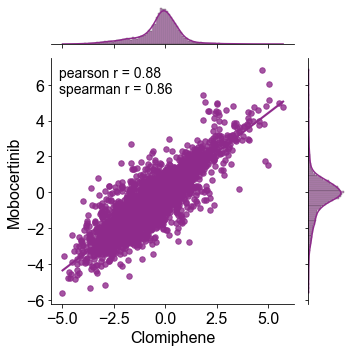

In [66]:
plot_scatter_with_corr(
    df=drug_matrix,
    x_col="Clomiphene (citrate)",
    y_col="Mobocertinib (succinate)",
    outdir = file_path_manual,
    color="#8E2A8B",
    height=5,
    tick_fontsize=16,
    label_fontsize=16,
    text_fontsize=14,
    dpi=600,
    show=True
)

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\Chlorpropamide_vs_Flumatinib_jointplot.svg


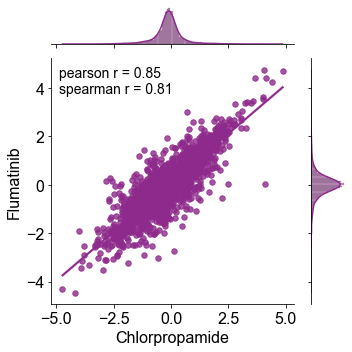

In [67]:
plot_scatter_with_corr(
    df=drug_matrix,
    x_col="Chlorpropamide",
    y_col="Flumatinib",
    outdir = file_path_manual,
    color="#8E2A8B",
    height=5,
    tick_fontsize=16,
    label_fontsize=16,
    text_fontsize=14,
    dpi=600,
    show=True
)

Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\Baicalein_vs_Binimetinib_jointplot.svg


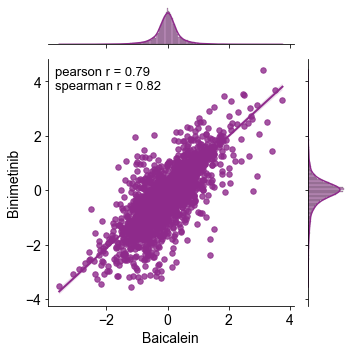

In [63]:
plot_scatter_with_corr(
    df=drug_matrix,
    x_col="Baicalein",
    y_col="Binimetinib",
    outdir = file_path_manual,
    color="#8E2A8B",
    height=5,
    tick_fontsize=16,
    label_fontsize=16,
    text_fontsize=14,
    dpi=600,
    show=True
)

In [64]:
pairs_df

,drug1,drug2,pearson,spearman
0,Clomiphene (citrate),Mobocertinib (succinate),0.875470,0.864579
1,Mefloquine (hydrochloride),Mobocertinib (succinate),0.863857,0.862313
2,Chlorpropamide,Flumatinib,0.854264,0.807072
3,Clomiphene (citrate),Mefloquine (hydrochloride),0.839912,0.832852
4,Baicalein,Binimetinib,0.790827,0.815247
5,Amiodarone (hydrochloride),Benztropine (mesylate),0.769228,0.765882
6,Chlorpropamide,Enclomiphene (citrate),0.764933,0.729434
7,Amiodarone (hydrochloride),Desloratadine,0.759243,0.746216
8,Amodiaquine (dihydrochloride),Desloratadine,0.748327,0.721258
9,Benztropine (mesylate),Desloratadine,0.735238,0.730990


Saved to: E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\Clomiphene_vs_Mefloquine_jointplot.svg


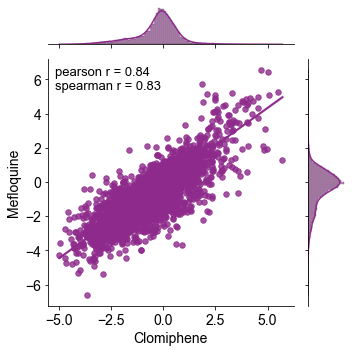

In [65]:
plot_scatter_with_corr(
    df=drug_matrix,
    x_col="Clomiphene (citrate)",
    y_col="Mefloquine (hydrochloride)",
    outdir = file_path_manual,
    color="#8E2A8B",
    height=5,
    tick_fontsize=14,
    label_fontsize=14,
    text_fontsize=13,
    dpi=600,
    show=True
)

C:\Users\jymbc\Anaconda3\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\jymbc\Anaconda3\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


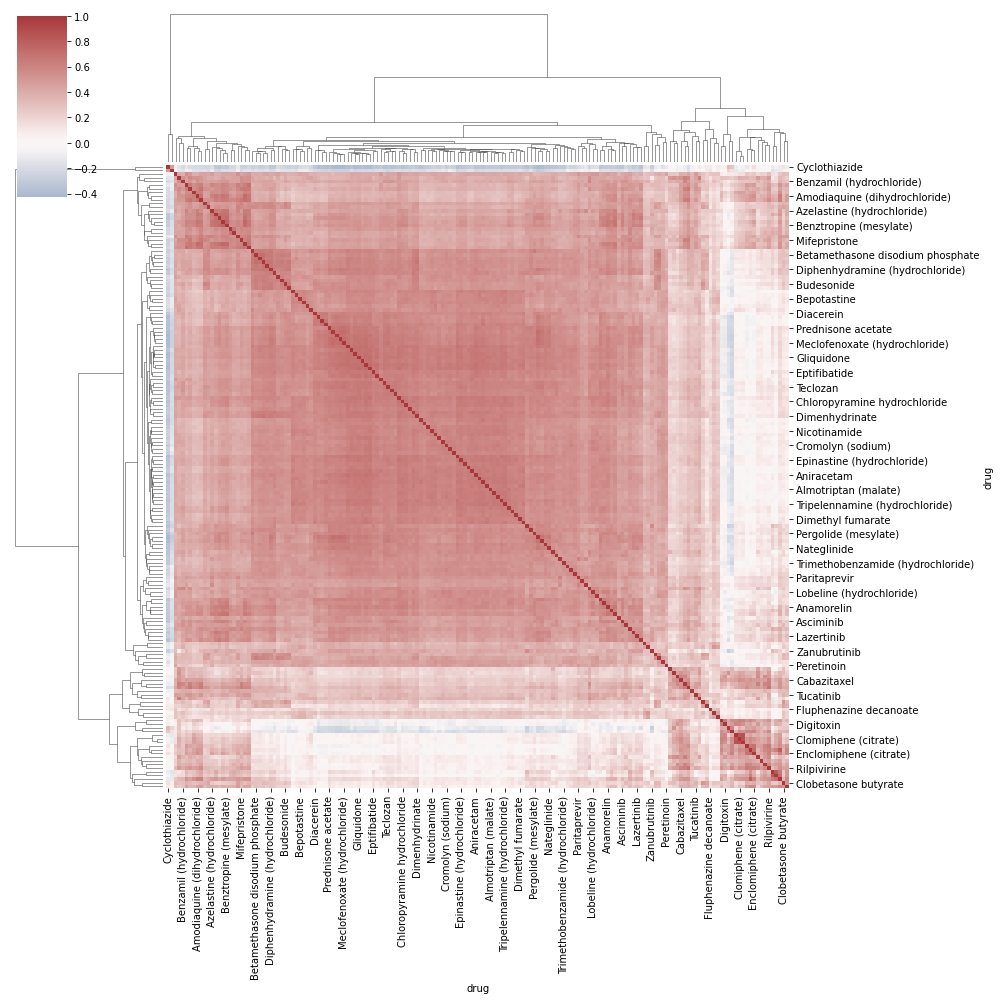

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(
    spearman_all,
    cmap="vlag",
    center=0,
    figsize=(14, 14)
)
plt.show()

In [6]:
# Keep only numeric columns (sample intensity columns)
df_num = df.select_dtypes(include=["number"])
df_num.shape

(8146, 1210)

In [9]:
def get_drug_name(col_name: str):
    """
    Map a raw column name to a 'drug name' group.

    Rules:
      - Columns containing '_QC' are treated as QC samples and EXCLUDED
        from drug correlation (return None).
      - Columns containing '_DFO' are grouped under drug name 'DFO'.
      - Columns containing '_DMSO' are grouped under drug name 'DMSO'.
      - Other columns:
          If they end with '_<number>' (e.g. 'Loratadine_3'),
          we strip the numeric suffix and use the prefix as drug name.
          Otherwise we return the full column name as-is.

    You can further customize this logic if your naming scheme changes.
    """

    # 1) Exclude QC samples completely
    if "_QC" in col_name:
        return None   # QC will not be used in drug_to_cols

    # 2) Map controls to consistent names
    if "DFO" in col_name:
        return "DFO"

    if "DMSO" in col_name:
        return "DMSO"

    # 3) Normal drugs with replicate suffix '_1', '_2', ...
    m = re.match(r"(.+)_([0-9]+)$", col_name)
    if m:
        return m.group(1)   # base drug name

    # 4) Fallback: keep the original name
    return col_name

In [10]:
# df_num: numeric matrix, index = Protein.Group, columns = samples
drug_to_cols = {}

for col in df_num.columns:
    drug = get_drug_name(col)
    # Skip QC or any column for which we returned None
    if drug is None:
        continue
    drug_to_cols.setdefault(drug, []).append(col)

print(f"Number of drug groups (including DMSO/DFO): {len(drug_to_cols)}")
print("Example keys:", list(drug_to_cols.keys())[:10])


Number of drug groups (including DMSO/DFO): 171
Example keys: ['DMSO', 'DFO', 'Triclabendazole', 'Camphor', 'Fexofenadine (hydrochloride)', 'Caroverine (hydrochloride)', 'Vadadustat', 'Tinoridine (hydrochloride)', 'Betamethasone disodium phosphate', 'Orelabrutinib']


In [14]:
# Pearson correlation between all sample (replicate) columns
sample_corr = df_num.corr(method="pearson")

In [15]:
sample_corr

,Caroverine (hydrochloride)_1,Tucatinib_1,Chloroprocaine (hydrochloride)_1,Liarozole_1,Aniracetam_1,Blue1_H1_DFO,Digitoxin_1,Clomiphene (citrate)_1,Betamethasone disodium phosphate_1,Blue1_A1_QC,...,Liranaftate_4,Cabazitaxel_4,Azelastine (hydrochloride)_2,Cabazitaxel_3,Redmix_G7_QC,Liranaftate_1,Paritaprevir_5,Latrepirdine (dihydrochloride)_2,Latrepirdine (dihydrochloride)_6,Cobicistat_3
Caroverine (hydrochloride)_1,1.000000,0.995853,0.995944,0.995816,0.995489,0.984677,0.987295,0.979166,0.995512,0.989071,...,0.995245,0.986733,0.988582,0.988668,0.989636,0.993655,0.990258,0.989408,0.986781,0.990988
Tucatinib_1,0.995853,1.000000,0.995911,0.995486,0.995395,0.985665,0.987220,0.981043,0.994879,0.988875,...,0.994126,0.987599,0.989557,0.988968,0.989283,0.992858,0.990619,0.989895,0.987768,0.991574
Chloroprocaine (hydrochloride)_1,0.995944,0.995911,1.000000,0.996428,0.996676,0.983348,0.985950,0.978081,0.995594,0.987579,...,0.994756,0.985842,0.987864,0.988287,0.989301,0.993544,0.989738,0.988638,0.985644,0.990907
Liarozole_1,0.995816,0.995486,0.996428,1.000000,0.996173,0.982063,0.986418,0.979106,0.995860,0.988115,...,0.995071,0.986155,0.987565,0.989167,0.989746,0.993931,0.989280,0.987626,0.985609,0.991525
Aniracetam_1,0.995489,0.995395,0.996676,0.996173,1.000000,0.982422,0.985842,0.978142,0.995508,0.987661,...,0.994651,0.985808,0.987494,0.988515,0.989546,0.993608,0.989323,0.988012,0.985575,0.991021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Liranaftate_1,0.993655,0.992858,0.993544,0.993931,0.993608,0.979551,0.984427,0.977337,0.993886,0.987022,...,0.995181,0.990102,0.991659,0.992554,0.989412,1.000000,0.992669,0.990879,0.989741,0.994822
Paritaprevir_5,0.990258,0.990619,0.989738,0.989280,0.989323,0.982389,0.982820,0.974411,0.988768,0.984729,...,0.990358,0.993168,0.995070,0.991531,0.985815,0.992669,1.000000,0.996341,0.994006,0.993041
Latrepirdine (dihydrochloride)_2,0.989408,0.989895,0.988638,0.987626,0.988012,0.982747,0.982506,0.972925,0.987537,0.983724,...,0.989023,0.992569,0.995254,0.989544,0.984235,0.990879,0.996341,1.000000,0.994081,0.991207
Latrepirdine (dihydrochloride)_6,0.986781,0.987768,0.985644,0.985609,0.985575,0.978575,0.981241,0.974476,0.986317,0.983089,...,0.985981,0.992874,0.994033,0.989626,0.982798,0.989741,0.994006,0.994081,1.000000,0.990726


In [17]:
import numpy as np

def compute_drug_similarity(
    df_num: pd.DataFrame,
    drug_to_cols: dict,
    sample_corr: pd.DataFrame,
    agg_func=np.nanmedian
) -> pd.DataFrame:
    """
    Compute drug–drug similarity using replicate-level correlations.

    For each pair of drugs (A, B):
      - Take all replicate columns of A and B.
      - Extract the submatrix of correlations corr(Ai, Bj).
      - Aggregate all values with agg_func (default: np.nanmedian).

    Returns:
        DataFrame of shape (n_drugs, n_drugs).
    """
    drugs = list(drug_to_cols.keys())
    drug_sim = pd.DataFrame(index=drugs, columns=drugs, dtype=float)

    for d1 in drugs:
        cols1 = drug_to_cols[d1]
        for d2 in drugs:
            cols2 = drug_to_cols[d2]

            # Replicate-level submatrix
            sub = sample_corr.loc[cols1, cols2].to_numpy().ravel()

            # Optionally drop perfect self-self correlations on diagonal
            if d1 == d2:
                sub = sub[sub < 0.999999]

            if sub.size > 0:
                drug_sim.loc[d1, d2] = agg_func(sub)
            else:
                drug_sim.loc[d1, d2] = np.nan

    return drug_sim


In [19]:
drug_similarity = compute_drug_similarity(df_num, drug_to_cols, sample_corr)
# drug_similarity.to_csv("drug_similarity_from_replicates_median.csv")

In [20]:
drug_similarity

,Caroverine (hydrochloride),Tucatinib,Chloroprocaine (hydrochloride),Liarozole,Aniracetam,DFO,Digitoxin,Clomiphene (citrate),Betamethasone disodium phosphate,Topiroxostat,...,Remdesivir,Ambroxol,Oteseconazole,Cabazitaxel,Cobicistat,Azelastine (hydrochloride),Efavirenz,Latrepirdine (dihydrochloride),Pergolide (mesylate),Paritaprevir
Caroverine (hydrochloride),0.997047,0.995854,0.995896,0.995588,0.995490,0.986684,0.987801,0.979706,0.996337,0.995753,...,0.986481,0.991589,0.990777,0.987000,0.989980,0.990902,0.993515,0.991058,0.994368,0.991714
Tucatinib,0.995854,0.996654,0.995911,0.995618,0.995511,0.986759,0.987359,0.981035,0.995408,0.995705,...,0.987275,0.991145,0.990509,0.987403,0.990758,0.991033,0.993416,0.991107,0.994582,0.991842
Chloroprocaine (hydrochloride),0.995896,0.995911,0.996728,0.996203,0.996449,0.985620,0.986970,0.979196,0.996177,0.996322,...,0.985920,0.991631,0.989816,0.986553,0.989639,0.990827,0.994302,0.990493,0.994858,0.992035
Liarozole,0.995588,0.995618,0.996203,0.996808,0.996142,0.984269,0.986214,0.979400,0.996015,0.996276,...,0.985739,0.991383,0.989318,0.986408,0.989321,0.989919,0.993542,0.990043,0.994770,0.991384
Aniracetam,0.995490,0.995511,0.996449,0.996142,0.996578,0.984937,0.986081,0.978650,0.995901,0.996319,...,0.985406,0.990938,0.988667,0.986007,0.989222,0.990316,0.993387,0.990193,0.994621,0.991340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Azelastine (hydrochloride),0.990902,0.991033,0.990827,0.989919,0.990316,0.981626,0.982536,0.977056,0.990036,0.990704,...,0.988897,0.994076,0.994014,0.991547,0.993617,0.995485,0.993510,0.994070,0.992638,0.994997
Efavirenz,0.993515,0.993416,0.994302,0.993542,0.993387,0.984088,0.985716,0.978514,0.993420,0.993531,...,0.989700,0.993971,0.992666,0.991107,0.992233,0.993510,0.995180,0.994132,0.994484,0.994553
Latrepirdine (dihydrochloride),0.991058,0.991107,0.990493,0.990043,0.990193,0.981551,0.982405,0.975834,0.990035,0.990309,...,0.988970,0.994740,0.993461,0.991493,0.992671,0.994070,0.994132,0.993941,0.992195,0.994664
Pergolide (mesylate),0.994368,0.994582,0.994858,0.994770,0.994621,0.983732,0.985037,0.979935,0.994456,0.994906,...,0.988125,0.992692,0.991578,0.988970,0.991290,0.992638,0.994484,0.992195,0.995326,0.993542


In [21]:
def show_drug_pair_similarity(
    drug1: str,
    drug2: str,
    drug_to_cols: dict,
    sample_corr: pd.DataFrame,
    agg_func=np.nanmedian
):
    """
    Show replicate-level correlation between two drugs and
    print an aggregated similarity value.

    Args:
        drug1, drug2: drug names (keys of drug_to_cols), e.g. "DMSO", "DFO",
                      "Caroverine (hydrochloride)", etc.
    """
    if drug1 not in drug_to_cols:
        raise ValueError(f"Drug '{drug1}' not found in drug_to_cols.")
    if drug2 not in drug_to_cols:
        raise ValueError(f"Drug '{drug2}' not found in drug_to_cols.")

    cols1 = drug_to_cols[drug1]
    cols2 = drug_to_cols[drug2]

    sub_corr = sample_corr.loc[cols1, cols2]
    values = sub_corr.to_numpy().ravel()

    if drug1 == drug2:
        values = values[values < 0.999999]

    agg_value = agg_func(values)

    print(f"\nReplicate correlations between '{drug1}' and '{drug2}':")
    print(sub_corr)

    print(f"\nAggregated similarity ({agg_func.__name__} of all replicate pairs): "
          f"{agg_value:.4f}")

In [22]:
# Example 1: one drug vs another drug
show_drug_pair_similarity(
    "Caroverine (hydrochloride)",
    "Tucatinib",
    drug_to_cols,
    sample_corr
)


Replicate correlations between 'Caroverine (hydrochloride)' and 'Tucatinib':
                              Tucatinib_1  Tucatinib_2  Tucatinib_3  \
Caroverine (hydrochloride)_1     0.995853     0.995827     0.995205   
Caroverine (hydrochloride)_2     0.995854     0.995887     0.995615   
Caroverine (hydrochloride)_3     0.995423     0.995705     0.996225   
Caroverine (hydrochloride)_4     0.995334     0.995345     0.995809   
Caroverine (hydrochloride)_5     0.995740     0.995850     0.995916   
Caroverine (hydrochloride)_6     0.995672     0.995866     0.995893   

                              Tucatinib_4  Tucatinib_5  Tucatinib_6  
Caroverine (hydrochloride)_1     0.995655     0.995210     0.995871  
Caroverine (hydrochloride)_2     0.996165     0.995928     0.996318  
Caroverine (hydrochloride)_3     0.996287     0.995544     0.995923  
Caroverine (hydrochloride)_4     0.995857     0.995565     0.995382  
Caroverine (hydrochloride)_5     0.996357     0.996062     0.996346  
Caro